In [17]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from tqdm.auto import tqdm
from scipy.optimize import minimize
from scipy.stats import chi2
import cvxpy as cp

In [18]:
data = pd.DataFrame([])
data_list = ['stock_monthly1991-2000', 'stock_monthly2001-2010', 'stock_monthly2011-2020']
for data_name in data_list:
    data = pd.concat([data, pd.read_pickle(data_name+'.pickle')]).reset_index(drop=True)
data['obs'] = data.groupby(['permno'])['month'].transform('nunique')
data = data[data['obs'] >= 300].reset_index(drop=True)
data = data.pivot(index='month', columns='permno', values='monthly_ret')
volatility = data.std()
low_vol_stocks = volatility.nsmallest(500).index
data = data[low_vol_stocks]

In [19]:
def Single_Period_Markowitz(returns_array, target_return=0.10, long_only=True):
    n_months, n_stocks = returns_array.shape
    mu = np.mean(returns_array, axis=0)
    sigma = np.cov(returns_array, rowvar=False) 
    
    # 初始化
    def portfolio_variance(w):
        return np.dot(w.T, np.dot(sigma, w))
    constraints = [
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0},
        {'type': 'eq', 'fun': lambda w: np.dot(w, mu) - target_return}
    ]
    if long_only:
        bounds = tuple((0.0, 1.0) for _ in range(n_stocks))
    else:
        bounds = tuple((None, None) for _ in range(n_stocks))
    init_weights = np.ones(n_stocks) / n_stocks

    # 求解
    opt_result = minimize(portfolio_variance, init_weights, method='SLSQP', bounds=bounds, constraints=constraints,
        # 增加精度和迭代次数以应对严格的等式约束
        options={'ftol': 1e-9, 'maxiter': 1000} 
    )
    optimal_weights = opt_result.x
    weights_col_vector = optimal_weights.reshape(-1, 1)
    
    return weights_col_vector

def Equal_Weighted(returns_array):
    n_stocks = returns_array.shape[1]
    weight = 1.0 / n_stocks
    weights_col_vector = np.full((n_stocks, 1), weight)
    return weights_col_vector

def DRMV(returns_array, target_rho, confidence_level=0.95, p_norm=2, long_only=True):
    """
    使用 CVXPY 构建的 DRMV-RWPI 二阶锥规划 (SOCP) 求解器。
    彻底解决 scipy SLSQP 的非平滑求导和不收敛问题。
    """
    returns_array = np.asarray(returns_array)
    n_months, n_stocks = returns_array.shape
    
    mu = np.mean(returns_array, axis=0)
    sigma = np.cov(returns_array, rowvar=False)
    
    # 1. 动态推导 delta 和 alpha_bar (RWPI逻辑保持不变)
    chi2_quantile = chi2.ppf(confidence_level, df=n_stocks) 
    delta = chi2_quantile / n_months  
    
    prior_weights = np.ones(n_stocks) / n_stocks
    prior_penalty = np.sqrt(delta) * np.linalg.norm(prior_weights, ord=p_norm)
    alpha_bar = target_rho - prior_penalty  
    
    # ================= 核心优化：CVXPY 凸优化重构 =================
    
    # 定义优化变量 (权重)
    w = cp.Variable(n_stocks)
    
    # 2. 处理协方差矩阵的平方根 (用于组合标准差)
    # 增加 1e-8 的微小对角矩阵，确保协方差矩阵严格正定，避免 Cholesky 分解报错
    sigma_safe = sigma + 1e-8 * np.eye(n_stocks)
    L = np.linalg.cholesky(sigma_safe)
    
    # 组合标准差 \sqrt{w^T \Sigma w} 在数学上等价于 2-范数 ||L^T w||_2
    portfolio_std = cp.norm(L.T @ w, 2)
    
    # 惩罚项 \sqrt{\delta} ||w||_p
    regularization = np.sqrt(delta) * cp.norm(w, p_norm)
    
    # 3. 定义目标函数：极小化
    objective = cp.Minimize(portfolio_std + regularization)
    
    # 4. 定义约束条件
    expected_return = mu @ w
    constraints = [
        cp.sum(w) == 1,
        expected_return >= alpha_bar + regularization
    ]
    
    if long_only:
        constraints.append(w >= 0)
        
    # 5. 构建并求解问题
    prob = cp.Problem(objective, constraints)
    
    try:
        # 使用底层非常稳健的 ECOS 或 SCS 求解器求解二阶锥问题
        prob.solve(solver=cp.ECOS) 
    except Exception as e:
        print(f"求解器底层异常: {e}")
        return np.ones((n_stocks, 1)) / n_stocks
        
    # 6. 状态检查
    if prob.status not in ["optimal", "optimal_inaccurate"]:
        print(f"警告：CVXPY 提示问题状态为: {prob.status}")
        print(f"诊断：这通常不是算法发散，而是给定的 target_rho ({target_rho}) 设定得太高。")
        print("在不允许做空和鲁棒惩罚的压力下，数学上不存在能达到该收益率的权重组合 (Infeasible)。")
        # 失败时退回等权组合，避免中断回测
        return np.ones((n_stocks, 1)) / n_stocks
        
    # 提取结果并转为列向量
    weights = w.value
    # 消除极端微小的浮点误差 (例如 -1e-12 强置为 0)
    if long_only:
        weights = np.clip(weights, 0, 1)
    # 重新归一化确保和为1
    weights = weights / np.sum(weights)
    
    return weights.reshape(-1, 1)

In [21]:
BACKTEST_START = "2001-01" 
BACKTEST_END   = "2016-12"
DATE = [d for d in data[(data.index >= BACKTEST_START) & (data.index <= BACKTEST_END)].index]
port_ret = {'Single_Period_Markowitz': [], 'Equal_Weighted': [], 'DRMV': []}
for i, date in enumerate(DATE):
    print('\r', date, end = '')
    data_cut = data.iloc[i:i+120+1]
    data_cut = data_cut.dropna(axis=1).sample(100, axis=1).values
    train_data = data_cut[:-1, :]
    test_data  = data_cut[-1:, :]
    weight_spm = Single_Period_Markowitz(train_data)
    port_ret['Single_Period_Markowitz'].append(test_data @ weight_spm)
    weight_ew = Equal_Weighted(train_data)
    port_ret['Equal_Weighted'].append(test_data @ weight_ew)
    weight_drvm = DRMV(train_data, 0.1)
    port_ret['DRMV'].append(test_data @ weight_drvm)
    break

 2001-01求解器底层异常: The solver ECOS is not installed.


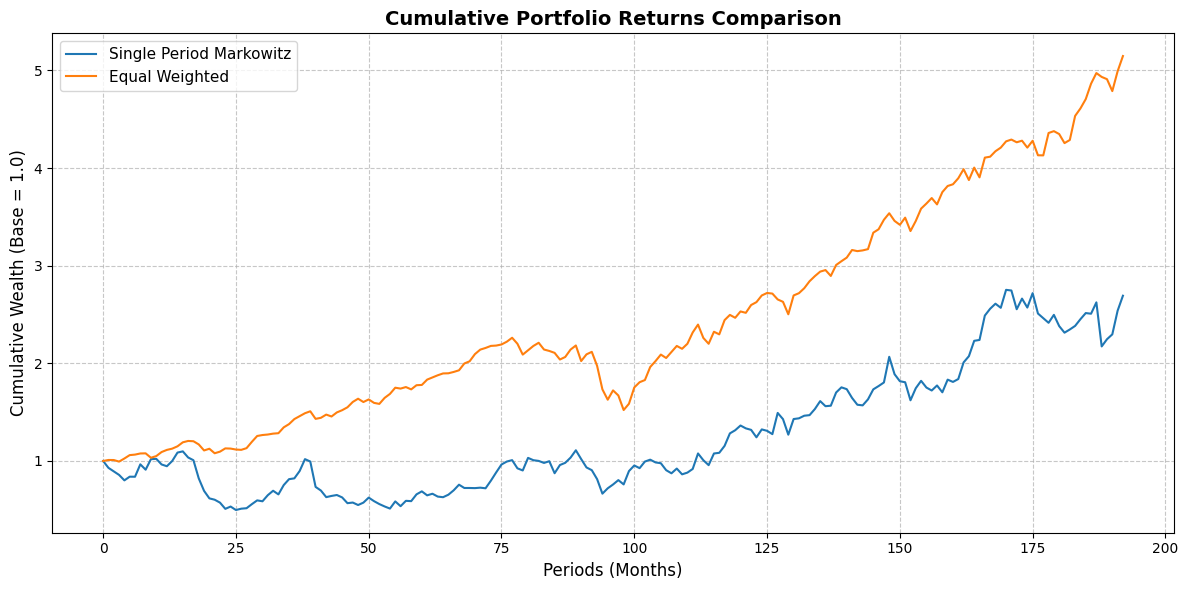

In [78]:
import numpy as np
import matplotlib.pyplot as plt

# 将您提供的数据赋值给变量 returns_data
# 这里由于篇幅省略了完整数据，请在实际运行时用您的完整字典替换 {...}
returns_data = port_ret

# 设置图表大小和清晰度
plt.figure(figsize=(12, 6), dpi=100)

# 遍历字典中的每一个策略
for strategy_name, returns_list in returns_data.items():
    # 1. 数据清洗：将 list 中嵌套的二维 array 转换为一维的浮点数序列
    # np.array(returns_list) 会生成一个 3D 数组，使用 flatten() 将其全部压平
    returns_array = np.array(returns_list).flatten()
    
    # 2. 计算累积回报：复利连乘公式 V_t = V_{t-1} * (1 + R_t)
    cumulative_returns = np.cumprod(1 + returns_array)
    
    # 3. 添加初始基准点 1.0，让所有曲线都从坐标 (0, 1.0) 开始
    cumulative_returns = np.insert(cumulative_returns, 0, 1.0)
    
    # 4. 绘制折线
    plt.plot(cumulative_returns, label=strategy_name.replace('_', ' '), linewidth=1.5)

# 设置图表的标题和坐标轴标签
plt.title('Cumulative Portfolio Returns Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Periods (Months)', fontsize=12)
plt.ylabel('Cumulative Wealth (Base = 1.0)', fontsize=12)

# 添加图例
plt.legend(loc='upper left', fontsize=11)

# 添加网格线，使图表更易读
plt.grid(True, linestyle='--', alpha=0.7)

# 优化边距并显示图表
plt.tight_layout()
plt.show()